<a href="https://colab.research.google.com/github/RevDra/final_project/blob/main/HTRU2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DS-AI PROJECT: PULSAR STAR DETECTION (HTRU2)
- **Project 18**: Detect pulsar stars using signal features
- **Author**: Lương Minh Ngọc
- **Student ID**: SE203746

---
## TABLE OF CONTENTS
1. Business Understanding & Data Preparation
2. Data Analysis (EDA)
3. Advanced Visualization
4. Chatbot Integration
5. Build Model & Evaluation
6. Conclusion & Application

## 1. Business Understanding & Data Preparation

- **OBJECTIVE**: Building a binary clasifier to detect Pulsar Star (Class 1) and noise (Class 0).
- **DATASET**: UCI-372 (HTRU2).
- **CHALLENGE**: Significantly imbalanced dataset.
- **SOLUTION**:
  - Use Stratified Sampling to split train/test sets.
  - Use Standard Scaling for SVM & Logistic Regression.

In [ ]:
!pip install ucimlrepo

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Load dataset
print("Loading HTRU2 dataset...")
htru2 = fetch_ucirepo(id=372)
X = htru2.data.features
y = htru2.data.targets

# 2. Check dataset
print(f"Shape: {X.shape}")
print("Class Distribution:\n", y.value_counts(normalize=True))

# 3. Split dataset (Stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Scaling
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

print("Data Preparation Complete!")

Loading HTRU2 dataset...
Shape: (17898, 8)
Class Distribution:
 class
0        0.908426
1        0.091574
Name: proportion, dtype: float64
Data Preparation Complete!


<>:34: SyntaxWarning: invalid escape sequence '\g'
<>:34: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_460/4096185460.py:34: SyntaxWarning: invalid escape sequence '\g'
  plt.text(4, 0.8, 'Class 1\n(Pulsar)\n$P \geq 0.5$', fontsize=11, ha='center', color='#000088')


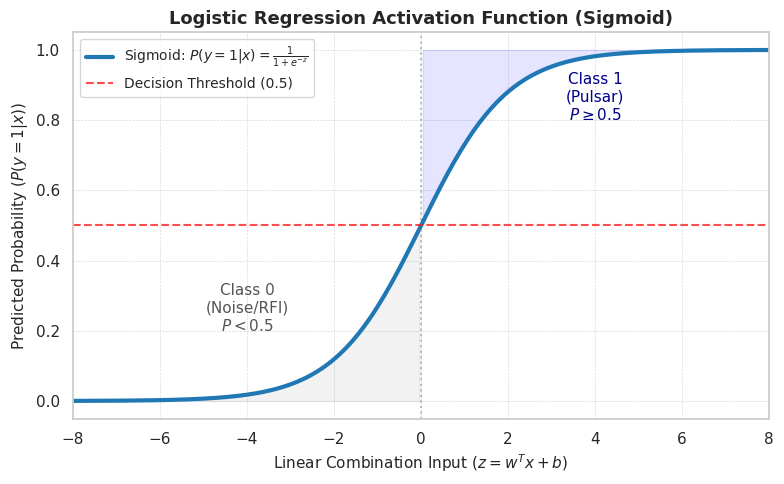

Đã lưu ảnh thành công: sigmoid_function.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Định nghĩa hàm Sigmoid ---
def sigmoid(z):
    """Tính giá trị sigmoid cho đầu vào z."""
    return 1 / (1 + np.exp(-z))

# --- 2. Tạo dữ liệu ---
# Tạo một dải giá trị z (đại diện cho tổ hợp tuyến tính w^Tx + b) từ -8 đến 8
z = np.linspace(-8, 8, 200)
# Tính xác suất P(y=1|x) tương ứng
p = sigmoid(z)

# --- 3. Vẽ biểu đồ ---
plt.figure(figsize=(8, 5)) # Kích thước phù hợp để chèn vào cột

# Vẽ đường cong Sigmoid
plt.plot(z, p, label=r'Sigmoid: $P(y=1|x) = \frac{1}{1 + e^{-z}}$', color='#1f77b4', linewidth=3)

# --- 4. Thêm các yếu tố chú thích ---
# Vẽ đường ngưỡng quyết định (Decision Threshold) tại P = 0.5
plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.7, linewidth=1.5, label='Decision Threshold (0.5)')

# Vẽ đường trục giữa tại z = 0
plt.axvline(x=0, color='gray', linestyle=':', alpha=0.5)

# Tô màu vùng Class 0 (Noise) và Class 1 (Pulsar)
plt.fill_between(z, p, 0, where=(z < 0), color='gray', alpha=0.1)
plt.fill_between(z, p, 1, where=(z >= 0), color='blue', alpha=0.1)

# Thêm text chú thích cho các vùng
plt.text(-4, 0.2, 'Class 0\n(Noise/RFI)\n$P < 0.5$', fontsize=11, ha='center', color='#555555')
plt.text(4, 0.8, 'Class 1\n(Pulsar)\n$P \geq 0.5$', fontsize=11, ha='center', color='#000088')

# --- 5. Tinh chỉnh giao diện ---
plt.title('Logistic Regression Activation Function (Sigmoid)', fontsize=13, fontweight='bold')
plt.xlabel('Linear Combination Input ($z = w^T x + b$)', fontsize=11)
plt.ylabel('Predicted Probability ($P(y=1|x)$)', fontsize=11)
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
plt.legend(fontsize=10, loc='upper left')
plt.xlim(-8, 8)
plt.ylim(-0.05, 1.05)

plt.tight_layout()

# Lưu ảnh với độ phân giải cao (300 DPI) để in ấn sắc nét
plt.savefig('sigmoid_function.png', dpi=300, bbox_inches='tight')

# Hiển thị ảnh (nếu chạy trên notebook)
plt.show()

print("Đã lưu ảnh thành công: sigmoid_function.png")

Đang tải dữ liệu HTRU2...


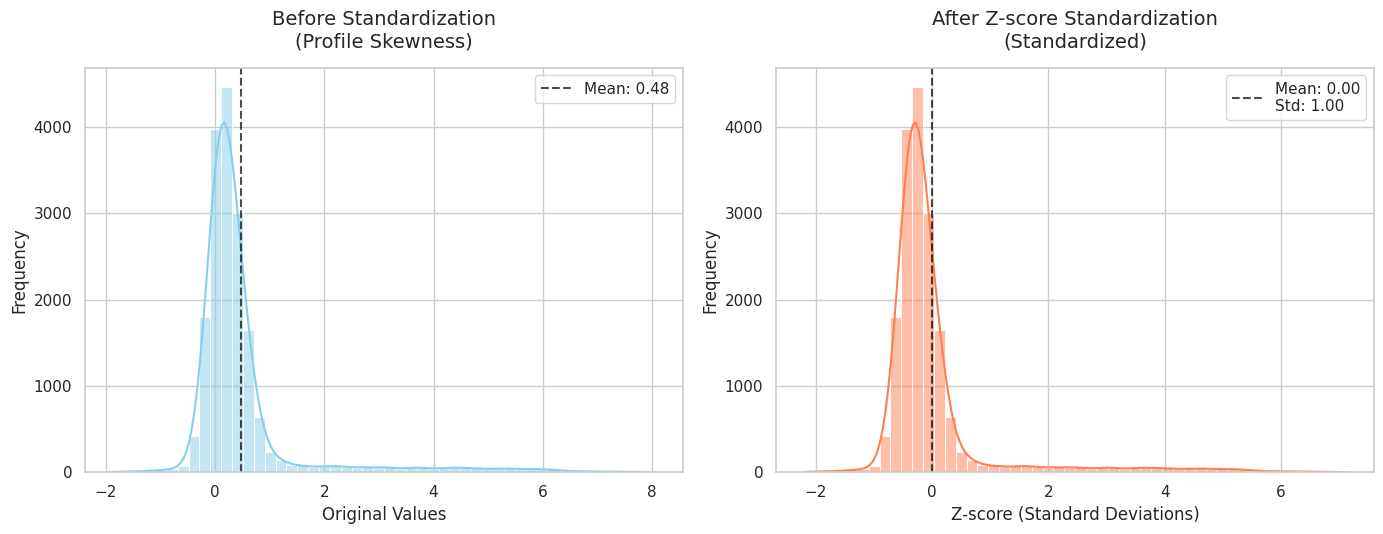

✅ Đã lưu ảnh thành công với tên 'zscore_before_after.png'


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from ucimlrepo import fetch_ucirepo

# 1. Load dataset (như code của bạn)
print("Đang tải dữ liệu HTRU2...")
htru2 = fetch_ucirepo(id=372)
X = htru2.data.features

# 2. Chọn một Feature để minh họa (Chọn cột Excess Kurtosis của Profile)
# Trong HTRU2, đây thường là cột thứ 3 (index 2)
feature_idx = 2
raw_feature = X.iloc[:, feature_idx]

# Tự động lấy tên cột để làm tiêu đề biểu đồ cho chuyên nghiệp
feature_name = X.columns[feature_idx]
# Rút gọn tên nếu quá dài (tùy chọn)
short_name = feature_name.replace('_', ' ').title()

# 3. Thực hiện chuẩn hóa Z-score
scaler = StandardScaler()
# Reshape(-1, 1) vì scikit-learn yêu cầu mảng 2D cho 1 cột
scaled_feature = scaler.fit_transform(raw_feature.values.reshape(-1, 1)).flatten()

# 4. Vẽ biểu đồ so sánh Side-by-Side
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
sns.set_theme(style="whitegrid") # Theme hiện đại

color_raw = "skyblue"
color_scaled = "coral"

# --- Biểu đồ 1: TRƯỚC khi chuẩn hóa ---
sns.histplot(raw_feature, kde=True, ax=axes[0], color=color_raw, bins=50)
axes[0].set_title(f'Before Standardization\n({short_name})', fontsize=14, pad=15)
axes[0].set_xlabel('Original Values', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)

# Đánh dấu Mean gốc
mean_raw = raw_feature.mean()
axes[0].axvline(mean_raw, color='black', linestyle='--', alpha=0.7, label=f'Mean: {mean_raw:.2f}')
axes[0].legend(loc='upper right')

# --- Biểu đồ 2: SAU khi chuẩn hóa (Z-score) ---
sns.histplot(scaled_feature, kde=True, ax=axes[1], color=color_scaled, bins=50)
axes[1].set_title(f'After Z-score Standardization\n(Standardized)', fontsize=14, pad=15)
axes[1].set_xlabel('Z-score (Standard Deviations)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)

# Đánh dấu Mean (0) và Std (1)
mean_scaled = scaled_feature.mean()
std_scaled = scaled_feature.std()
axes[1].axvline(mean_scaled, color='black', linestyle='--', alpha=0.7, label=f'Mean: {mean_scaled:.2f}\nStd: {std_scaled:.2f}')
axes[1].legend(loc='upper right')

# 5. Căn chỉnh layout và lưu ảnh cho bài báo
plt.tight_layout()
plt.savefig('zscore_before_after.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Đã lưu ảnh thành công với tên 'zscore_before_after.png'")

## 2. Data Analysis (EDA)
Analyze distribution of features to find differences between Pulsar Star and Noise.

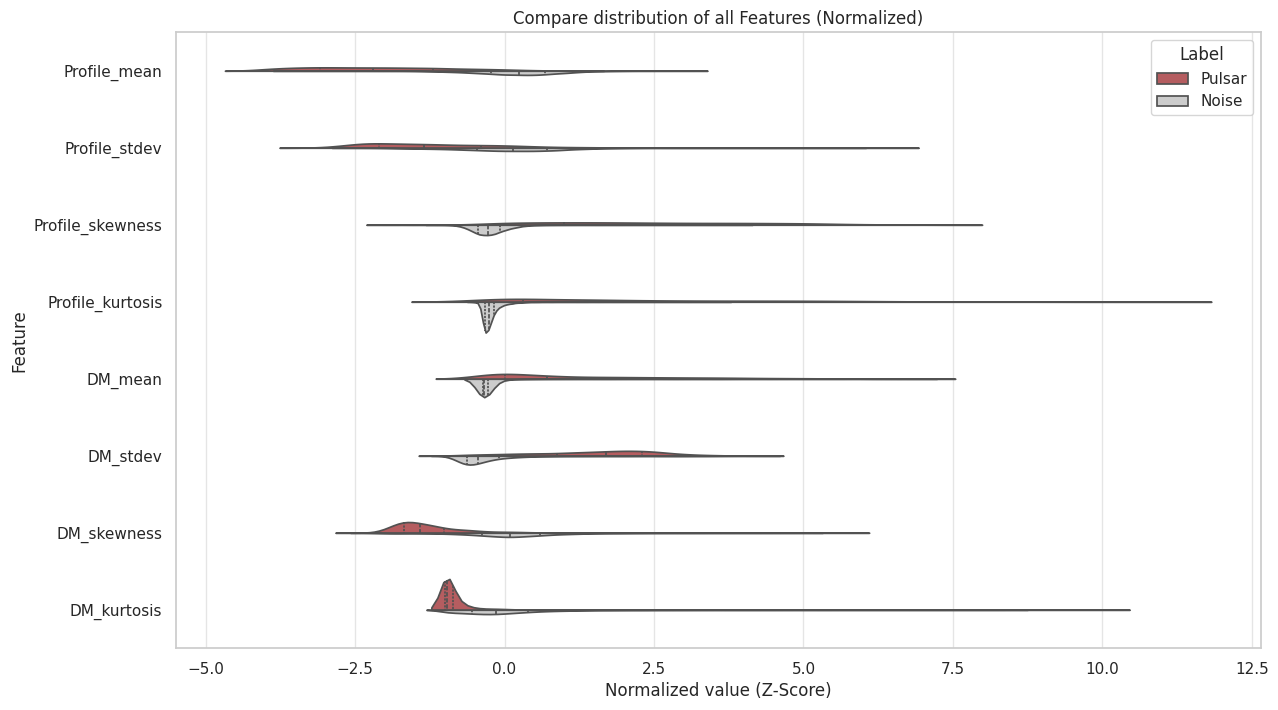

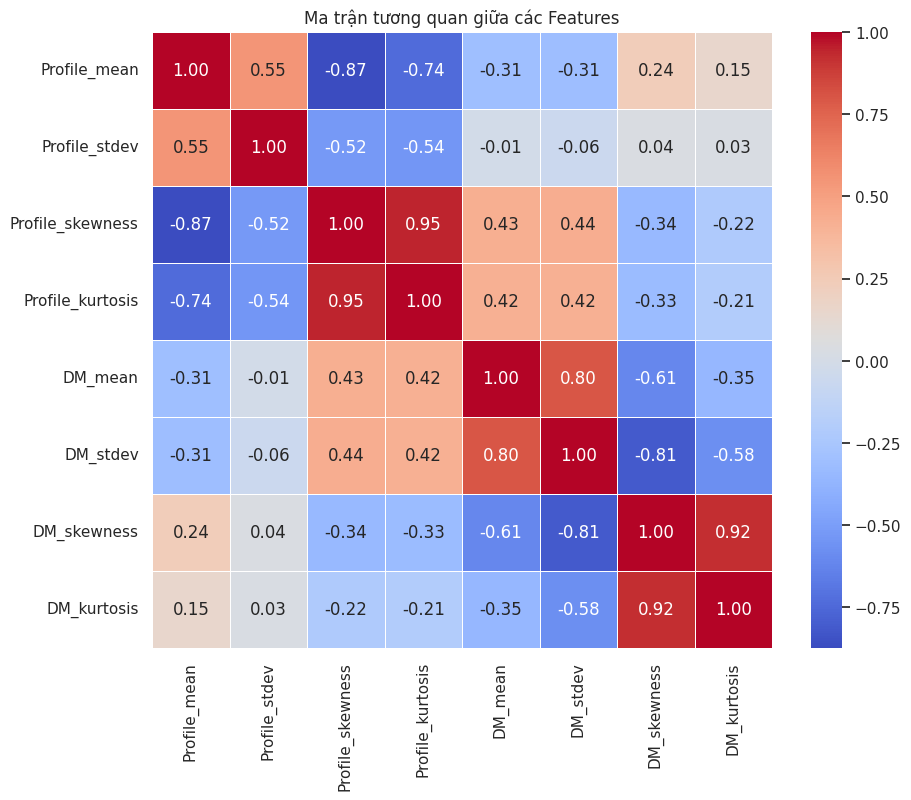

In [ ]:
# --- CHUẨN BỊ DỮ LIỆU ĐỂ VẼ ---
# Copy dữ liệu đã scale
df_all = X_train_scaled.copy()

# SỬA LỖI Ở ĐÂY:
# Dùng .values.ravel() để chuyển y_train thành mảng 1 chiều trước khi xử lý
# Cách này chạy đúng bất kể y_train là DataFrame hay Series
y_array = y_train.values.ravel()

# Tạo cột Label
df_all['Label'] = ['Pulsar' if x == 1 else 'Noise' for x in y_array]

# Chuyển dữ liệu sang dạng dọc (Long format) để vẽ gộp
df_melted = pd.melt(df_all, id_vars=['Label'], var_name='Feature', value_name='Normalized Value')

# 2. Vẽ Violin Plot
plt.figure(figsize=(14, 8))
sns.violinplot(
    data=df_melted,
    x='Normalized Value',
    y='Feature',
    hue='Label',
    split=True,
    inner="quart",
    palette={"Noise": "0.8", "Pulsar": "r"}
)

plt.title('Compare distribution of all Features (Normalized)')
plt.xlabel('Normalized value (Z-Score)')
plt.grid(True, axis='x', alpha=0.5)
plt.show()

# 3. Vẽ Correlation Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(X_train_scaled.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Ma trận tương quan giữa các Features')
plt.show()

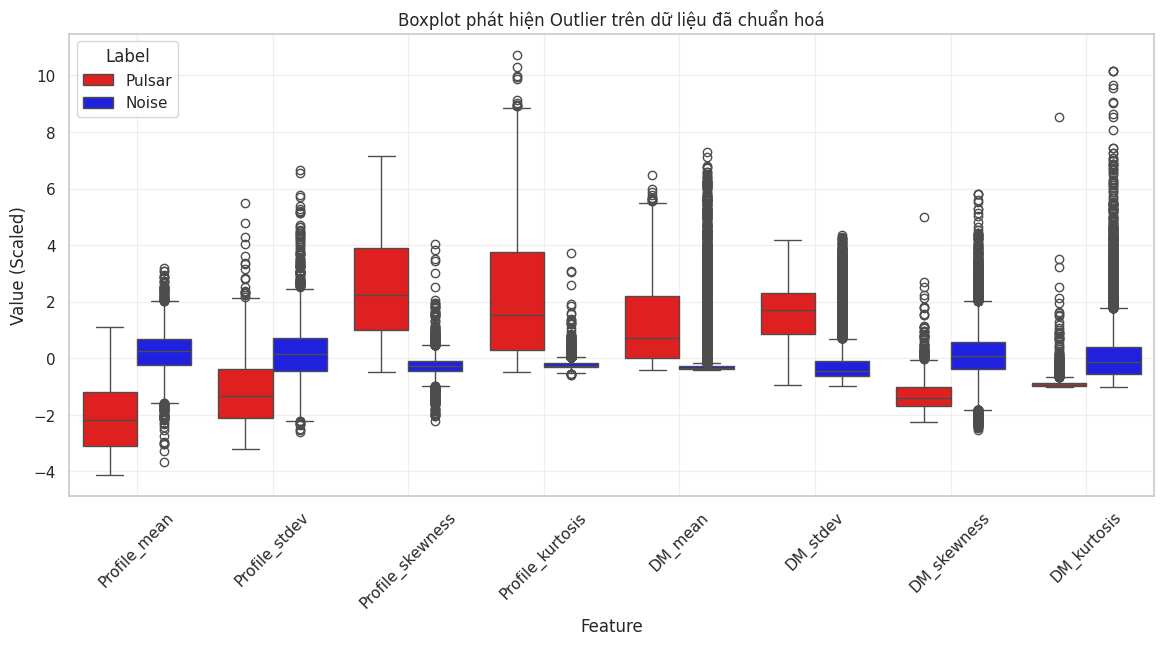

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- CHUẨN BỊ DỮ LIỆU ĐỂ VẼ ---
# Chúng ta nối X_train và y_train lại để dùng seaborn cho tiện
# Lưu ý: Dùng dữ liệu ĐÃ SCALE (X_train_scaled) để so sánh các đặc trưng trên cùng 1 trục tung
df_eda = X_train_scaled.copy()
df_eda['Class'] = y_train.values  # 0: Noise, 1: Pulsar

# Đổi tên Class để biểu đồ dễ đọc hơn
df_eda['Label'] = df_eda['Class'].apply(lambda x: 'Pulsar' if x == 1 else 'Noise')

# --- BIỂU ĐỒ 2: KIỂM TRA OUTLIERS (BOXPLOT) ---
# Vẽ boxplot cho tất cả đặc trưng để thấy outlier
plt.figure(figsize=(14, 6))
# Chuyển dữ liệu về dạng "long" để vẽ boxplot gộp
df_long = pd.melt(df_eda, id_vars=['Class', 'Label'], var_name='Feature', value_name='Value (Scaled)')

sns.boxplot(data=df_long, x='Feature', y='Value (Scaled)', hue='Label', palette=['red', 'blue'])
plt.xticks(rotation=45)
plt.title('Boxplot phát hiện Outlier trên dữ liệu đã chuẩn hoá')
plt.grid(True, alpha=0.3)
plt.show()

## 3. Advanced Visualization
Use 2D space graph (PCA) or Precision-Recall Curve to evaluate the dataset.

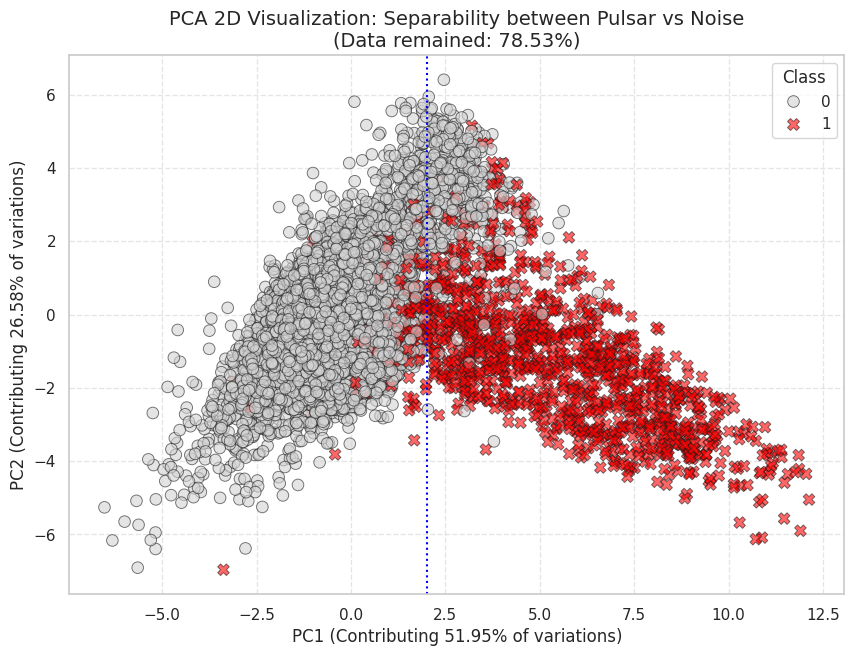

--- Ý NGHĨA CÁC TRỤC CHÍNH (PCA COMPONENTS) ---

Top 3 features đóng góp vào PC1 (Trục hoành):
Profile_skewness    0.415965
Profile_kurtosis    0.401020
DM_stdev            0.385239
Name: PC1, dtype: float64

Top 3 features đóng góp vào PC2 (Trục tung):
Profile_stdev    0.426583
DM_skewness      0.414035
DM_kurtosis      0.403092
Name: PC2, dtype: float64


In [ ]:
from sklearn.decomposition import PCA

# ==========================================================
# PHẦN 3: ADVANCED VISUALIZATION - PCA 2D
# Mục tiêu: Nén 8 chiều dữ liệu xuống 2 chiều để kiểm tra tính phân tách
# ==========================================================

# 1. Thực hiện PCA
# Lưu ý: PCA cực kỳ nhạy cảm với dữ liệu chưa scale.
# Ta dùng X_train_scaled đã tạo ở Phần 1.
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)

# 2. Chuẩn bị DataFrame để vẽ
df_pca = pd.DataFrame(X_pca, columns=['Principal Component 1', 'Principal Component 2'])
df_pca['Label'] = y_train.values.ravel() # 0: Noise, 1: Pulsar

# Tính toán lượng thông tin (variance) giữ lại được
var_ratio = pca.explained_variance_ratio_
total_var = sum(var_ratio)

# 3. Vẽ biểu đồ Scatter Plot 2D
plt.figure(figsize=(10, 7))
scatter = sns.scatterplot(
    data=df_pca,
    x='Principal Component 1',
    y='Principal Component 2',
    hue='Label',
    style='Label',
    palette={0: 'lightgray', 1: 'red'}, # Noise màu xám, Pulsar màu đỏ
    alpha=0.6,
    s=70,
    edgecolor='k' # Viền đen cho điểm để rõ hơn
)

# Trang trí biểu đồ
plt.title(f'PCA 2D Visualization: Separability between Pulsar vs Noise\n(Data remained: {total_var:.2%})', fontsize=14)
plt.xlabel(f'PC1 (Contributing {var_ratio[0]:.2%} of variations)', fontsize=12)
plt.ylabel(f'PC2 (Contributing {var_ratio[1]:.2%} of variations)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Class', loc='upper right')

# Vẽ đường ranh giới tượng trưng (chỉ để minh hoạ ý tưởng phân tách)
# Lưu ý: Đây không phải ranh giới thực của mô hình, chỉ để visual
plt.axvline(x=2, color='blue', linestyle=':', label='Ranh giới tiềm năng')

plt.show()

# 4. Phân tích thành phần (Để hiểu PC1 và PC2 đại diện cho cái gì)
print("--- Ý NGHĨA CÁC TRỤC CHÍNH (PCA COMPONENTS) ---")
components_df = pd.DataFrame(pca.components_, columns=X.columns, index=['PC1', 'PC2'])

print("\nTop 3 features đóng góp vào PC1 (Trục hoành):")
print(components_df.loc['PC1'].abs().sort_values(ascending=False).head(3))

print("\nTop 3 features đóng góp vào PC2 (Trục tung):")
print(components_df.loc['PC2'].abs().sort_values(ascending=False).head(3))

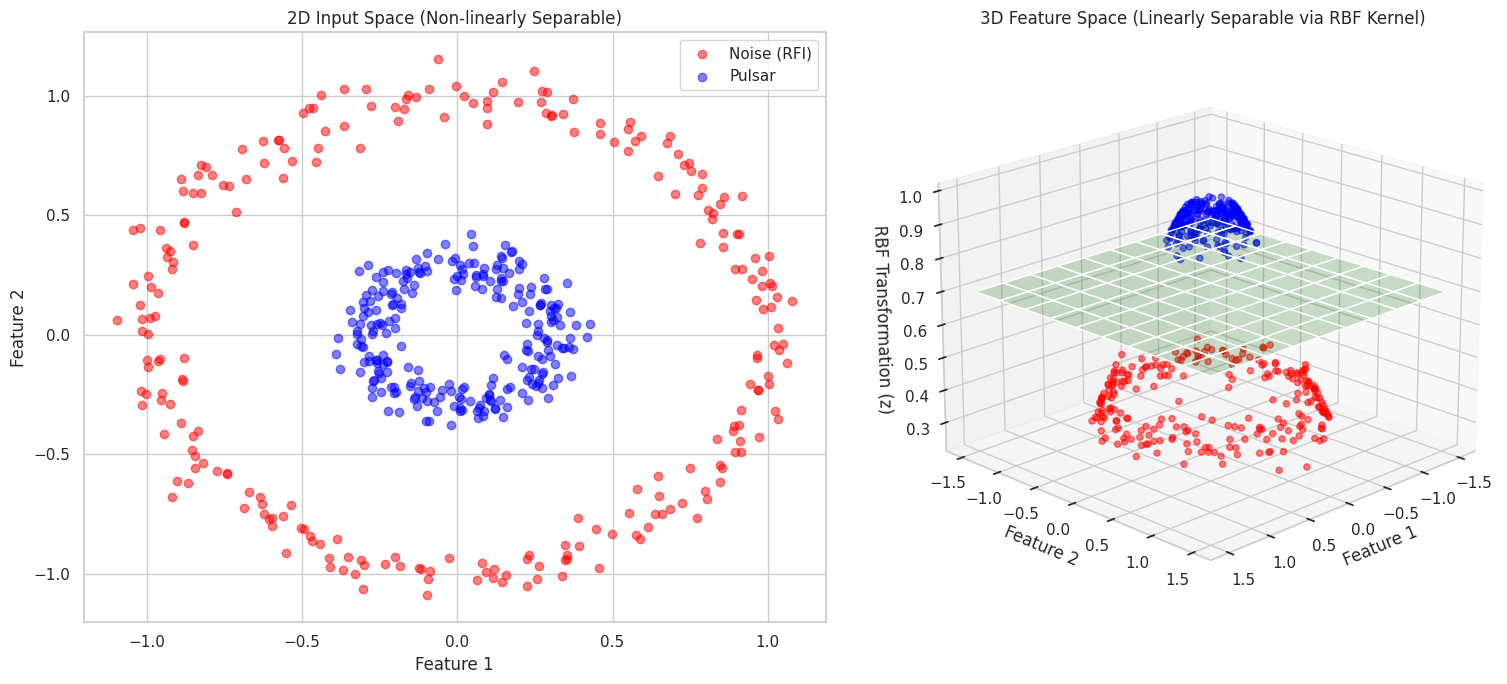

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from mpl_toolkits.mplot3d import Axes3D

# 1. Tạo dữ liệu giả lập dạng hình tròn (không thể phân tách tuyến tính ở 2D)
X, y = make_circles(n_samples=500, factor=0.3, noise=0.05, random_state=42)

# 2. Định nghĩa hàm biến đổi RBF đơn giản (đưa lên chiều thứ 3)
# z = exp(-(x^2 + y^2)) - đây là hạt nhân của RBF
z = np.exp(-(X[:, 0]**2 + X[:, 1]**2))

# 3. Khởi tạo figure
fig = plt.figure(figsize=(16, 7))

# --- Trục bên trái: Không gian 2D (Input Space) ---
ax1 = fig.add_subplot(121)
ax1.scatter(X[y == 0, 0], X[y == 0, 1], color='red', alpha=0.5, label='Noise (RFI)')
ax1.scatter(X[y == 1, 0], X[y == 1, 1], color='blue', alpha=0.5, label='Pulsar')
ax1.set_title("2D Input Space (Non-linearly Separable)")
ax1.set_xlabel("Feature 1")
ax1.set_ylabel("Feature 2")
ax1.legend()

# --- Trục bên phải: Không gian 3D (Feature Space) ---
ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(X[y == 0, 0], X[y == 0, 1], z[y == 0], color='red', alpha=0.5)
ax2.scatter(X[y == 1, 0], X[y == 1, 1], z[y == 1], color='blue', alpha=0.5)

# Vẽ một mặt phẳng (Hyperplane) phân tách ở giữa
xx, yy = np.meshgrid(np.linspace(-1.5, 1.5, 10), np.linspace(-1.5, 1.5, 10))
zz = np.full(xx.shape, 0.7) # Mặt phẳng cắt ngang ở z = 0.7
ax2.plot_surface(xx, yy, zz, alpha=0.2, color='green')

ax2.set_title("3D Feature Space (Linearly Separable via RBF Kernel)")
ax2.set_xlabel("Feature 1")
ax2.set_ylabel("Feature 2")
ax2.set_zlabel("RBF Transformation (z)")
ax2.view_init(elev=20, azim=45) # Chỉnh góc nhìn cho đẹp

plt.tight_layout()
# Lưu ảnh với độ phân giải cao để chèn vào LaTeX
plt.savefig('rbf_kernel_trick.png', dpi=300)
plt.show()

## 5. Build Model & Evaluation
Build & compare 3 models:
1. Majority Class (Baseline)
2. Logistic Regression (Class Weight)
3. RBF SVM (Class Weight)

Evaluate based on PR-AUC & F1-Score.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_validate, StratifiedKFold
# Các hàm quan trọng để tính toán và hiển thị chỉ số
from sklearn.metrics import (
    make_scorer,
    precision_recall_curve,
    f1_score,
    average_precision_score,
    roc_auc_score,
    PrecisionRecallDisplay
)

# ==========================================================
# PHẦN 5: BUILD MODEL & EVALUATION (CẬP NHẬT)
# ==========================================================

# 1. Định nghĩa hàm tính Recall tại Precision 0.9
def recall_at_precision_09(y_true, y_probs):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_probs)
    # Tìm các vị trí mà Precision >= 0.9
    idx = np.where(precisions >= 0.9)[0]
    if len(idx) > 0:
        # Trả về recall cao nhất tại hoặc trên ngưỡng precision 0.9
        return recalls[idx[0]]
    return 0.0 # Trả về 0.0 nếu không tìm thấy ngưỡng

# Tạo custom scorer để dùng trong cross_validate
# Sử dụng response_method='predict_proba' để đảm bảo hàm nhận được xác suất
custom_scorer = make_scorer(recall_at_precision_09, response_method='predict_proba')

# 2. Cập nhật bộ chỉ số đánh giá (scoring)
scoring = {
    'PR_AUC': 'average_precision',
    'F1': 'f1',
    'ROC_AUC': 'roc_auc',
    'Recall_at_09': custom_scorer
}

# 3. Chạy huấn luyện và đánh giá với K-Fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define the models dictionary
models = {
    "Majority (Baseline)": DummyClassifier(strategy="most_frequent", random_state=42),
    "Logistic Regression": LogisticRegression(solver='liblinear', random_state=42, class_weight='balanced'),
    "RBF SVC": SVC(kernel='rbf', gamma='scale', random_state=42, probability=True, class_weight='balanced')
}

# Điều chỉnh tiêu đề bảng để chứa thêm cột
header = f"{'Model':<20} | {'PR-AUC':<16} | {'F1':<16} | {'ROC-AUC':<16} | {'Recall@P.9':<16}"
print(header)
print("-" * len(header))

trained_models = {}

for name, model in models.items():
    # Cross Validation
    #ravel() được dùng để tránh cảnh báo DataConversionWarning
    scores = cross_validate(model, X_train_scaled, y_train.values.ravel(), cv=cv, scoring=scoring)

    # Trích xuất kết quả
    metrics = {
        'PR_AUC': (scores['test_PR_AUC'].mean(), scores['test_PR_AUC'].std()),
        'F1': (scores['test_F1'].mean(), scores['test_F1'].std()),
        'ROC_AUC': (scores['test_ROC_AUC'].mean(), scores['test_ROC_AUC'].std()),
        'Recall_at_09': (scores['test_Recall_at_09'].mean(), scores['test_Recall_at_09'].std())
    }

    print(f"{name:<20} | "
          f"{metrics['PR_AUC'][0]:.4f}±{metrics['PR_AUC'][1]:.3f} | "
          f"{metrics['F1'][0]:.4f}±{metrics['F1'][1]:.3f} | "
          f"{metrics['ROC_AUC'][0]:.4f}±{metrics['ROC_AUC'][1]:.3f} | "
          f"{metrics['Recall_at_09'][0]:.4f}±{metrics['Recall_at_09'][1]:.3f}")

    # Huấn luyện lại trên toàn bộ tập Train
    model.fit(X_train_scaled, y_train.values.ravel())
    trained_models[name] = model

Model                | PR-AUC           | F1               | ROC-AUC          | Recall@P.9      
------------------------------------------------------------------------------------------------
Majority (Baseline)  | 0.0916±0.000 | 0.0000±0.000 | 0.5000±0.000 | 0.0000±0.000
Logistic Regression  | 0.9232±0.013 | 0.8417±0.012 | 0.9770±0.004 | 0.8666±0.039
RBF SVC              | 0.8739±0.013 | 0.8618±0.008 | 0.9744±0.003 | 0.8734±0.035


In [ ]:
from sklearn.model_selection import GridSearchCV

# ==========================================================
# PHẦN 5: BUILD MODEL & HYPERPARAMETER TUNING (CẬP NHẬT)
# ==========================================================

# 1. Định nghĩa không gian tìm kiếm (Search Space)
param_grids = {
    "Logistic Regression": {
        'C': [0.1, 1, 10, 100]
    },
    "RBF SVC": {
        'C': [0.1, 1, 10, 100],
        'gamma': [0.001, 0.01, 0.1, 1]
    }
}

# 2. Khởi tạo lại dictionary mô hình (Sử dụng GridSearchCV làm estimator)
# Scoring của vòng lặp trong là 'average_precision' để tối ưu PR-AUC
tuned_models = {}

print(f"{'Model':<20} | {'PR-AUC':<16} | {'F1':<16} | {'ROC-AUC':<16} | {'Recall@P.9':<16}")
print("-" * 88)

final_best_params = {}

for name, model in models.items():
    if name == "Majority (Baseline)":
        # Baseline không cần tuning
        scores = cross_validate(model, X_train_scaled, y_train.values.ravel(), cv=cv, scoring=scoring)
        search_object = model
    else:
        # Thiết lập Grid Search cho vòng lặp trong (Inner CV)
        # CV=3 hoặc 5 tùy thuộc vào thời gian chạy bạn có
        grid_search = GridSearchCV(
            estimator=model,
            param_grid=param_grids[name],
            scoring='average_precision',
            cv=3,
            n_jobs=-1
        )

        # Chạy Nested Cross-Validation (Outer CV)
        scores = cross_validate(grid_search, X_train_scaled, y_train.values.ravel(), cv=cv, scoring=scoring)
        search_object = grid_search

    # Trích xuất kết quả trung bình từ các fold ngoài
    metrics = {
        'PR_AUC': (scores['test_PR_AUC'].mean(), scores['test_PR_AUC'].std()),
        'F1': (scores['test_F1'].mean(), scores['test_F1'].std()),
        'ROC_AUC': (scores['test_ROC_AUC'].mean(), scores['test_ROC_AUC'].std()),
        'Recall_at_09': (scores['test_Recall_at_09'].mean(), scores['test_Recall_at_09'].std())
    }

    print(f"{name:<20} | "
          f"{metrics['PR_AUC'][0]:.4f}±{metrics['PR_AUC'][1]:.3f} | "
          f"{metrics['F1'][0]:.4f}±{metrics['F1'][1]:.3f} | "
          f"{metrics['ROC_AUC'][0]:.4f}±{metrics['ROC_AUC'][1]:.3f} | "
          f"{metrics['Recall_at_09'][0]:.4f}±{metrics['Recall_at_09'][1]:.3f}")

    # 4. Huấn luyện lại trên TOÀN BỘ tập Train để tìm Best Params cuối cùng cho Chatbot
    search_object.fit(X_train_scaled, y_train.values.ravel())

    if name != "Majority (Baseline)":
        final_best_params[name] = search_object.best_params_
        trained_models[name] = search_object.best_estimator_
    else:
        trained_models[name] = search_object

print("\n--- Best Parameters Found ---")
for name, params in final_best_params.items():
    print(f"{name}: {params}")

Model                | PR-AUC           | F1               | ROC-AUC          | Recall@P.9      
----------------------------------------------------------------------------------------
Majority (Baseline)  | 0.0916±0.000 | 0.0000±0.000 | 0.5000±0.000 | 0.0000±0.000
Logistic Regression  | 0.9226±0.012 | 0.8406±0.011 | 0.9768±0.004 | 0.8666±0.039
RBF SVC              | 0.9268±0.012 | 0.8680±0.008 | 0.9788±0.003 | 0.8635±0.040

--- Best Parameters Found ---
Logistic Regression: {'C': 0.1}
RBF SVC: {'C': 100, 'gamma': 0.001}


In [ ]:
scores['test_PR_AUC']

array([0.90410354, 0.92835898, 0.93050778, 0.94042591, 0.93057245])

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# ==========================================================
# 1. CHUẨN BỊ DỮ LIỆU & MÔ HÌNH
# ==========================================================
# Giả sử X_train, y_train đã có từ các bước trước
# Scale dữ liệu (Quan trọng cho SVC)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Định nghĩa 2 mô hình với tham số TỐI ƯU bạn đã tìm được
# LogReg: C=0.1
logreg_opt = LogisticRegression(C=0.1, class_weight='balanced', solver='liblinear', random_state=42)

# SVC: C=100, gamma=0.001 (và probability=True)
svc_opt = SVC(C=100, gamma=0.001, kernel='rbf', class_weight='balanced', probability=True, random_state=42)

# Thiết lập K-Fold (5 Folds)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Chỉ định metric muốn đo (PR-AUC)
scoring = {'PR_AUC': 'average_precision'}

print("⏳ Đang chạy Cross-Validation 5-Fold (có thể mất vài phút cho SVC)...")

# ==========================================================
# 2. CHẠY CROSS-VALIDATION & LẤY MẢNG ĐIỂM SỐ
# ==========================================================

# --- Chạy Logistic Regression ---
scores_lr = cross_validate(logreg_opt, X_train_scaled, y_train.values.ravel(),
                           cv=cv, scoring=scoring)
# Lấy mảng điểm số thực tế từ 5 fold
pr_auc_lr_folds = scores_lr['test_PR_AUC']

# --- Chạy RBF SVC ---
scores_svc = cross_validate(svc_opt, X_train_scaled, y_train.values.ravel(),
                            cv=cv, scoring=scoring)
# Lấy mảng điểm số thực tế từ 5 fold
pr_auc_svc_folds = scores_svc['test_PR_AUC']

# ==========================================================
# 3. THỰC HIỆN KIỂM ĐỊNH THỐNG KÊ (PAIRED T-TEST)
# ==========================================================

# In ra các giá trị thực tế để kiểm tra
print("\n--- KẾT QUẢ TỪNG FOLD (PR-AUC) ---")
print(f"LogReg Folds: {pr_auc_lr_folds}")
print(f"SVC Folds:    {pr_auc_svc_folds}")

# Tính Mean và Std
mean_diff = np.mean(pr_auc_svc_folds - pr_auc_lr_folds)

# Kiểm định t bắt cặp (Paired t-test)
# Đây là bước quan trọng xác định sự khác biệt có ý nghĩa hay không
t_stat, p_val = stats.ttest_rel(pr_auc_svc_folds, pr_auc_lr_folds)

# Tính khoảng tin cậy 95% (95% CI) cho sự khác biệt
# Công thức: Mean_diff ± t_critical * SE
df = len(pr_auc_lr_folds) - 1
se = stats.sem(pr_auc_svc_folds - pr_auc_lr_folds) # Standard Error
ci = stats.t.interval(0.95, df, loc=mean_diff, scale=se)

print("\n--- KẾT QUẢ KIỂM ĐỊNH (SIGNIFICANCE TEST) ---")
print(f"Mean Difference (SVC - LogReg): {mean_diff:.4f}")
print(f"P-value: {p_val:.4f}")
print(f"95% Confidence Interval: [{ci[0]:.4f}, {ci[1]:.4f}]")

print("-" * 50)
if p_val < 0.05:
    print("✅ KẾT LUẬN: Sự vượt trội của SVC có ý nghĩa thống kê (Significant).")
    print("   -> Bạn có thể viết trong bài báo: 'p < 0.05'")
else:
    print("❌ KẾT LUẬN: Chưa tìm thấy sự khác biệt có ý nghĩa thống kê.")
    print("   -> Bạn nên viết: 'difference was not statistically significant (p > 0.05)'")

⏳ Đang chạy Cross-Validation 5-Fold (có thể mất vài phút cho SVC)...

--- KẾT QUẢ TỪNG FOLD (PR-AUC) ---
LogReg Folds: [0.89845815 0.92920544 0.92422766 0.93382417 0.93481765]
SVC Folds:    [0.90410354 0.92835898 0.93050778 0.94042591 0.93057245]

--- KẾT QUẢ KIỂM ĐỊNH (SIGNIFICANCE TEST) ---
Mean Difference (SVC - LogReg): 0.0027
P-value: 0.2905
95% Confidence Interval: [-0.0034, 0.0088]
--------------------------------------------------
❌ KẾT LUẬN: Chưa tìm thấy sự khác biệt có ý nghĩa thống kê.
   -> Bạn nên viết: 'difference was not statistically significant (p > 0.05)'


<>:38: SyntaxWarning: invalid escape sequence '\p'
<>:38: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_460/2789784280.py:38: SyntaxWarning: invalid escape sequence '\p'
  ax.axvline(t_crit, color='red', linestyle=':', linewidth=2, label=f'Critical $t$-value = $\pm${t_crit:.2f}')


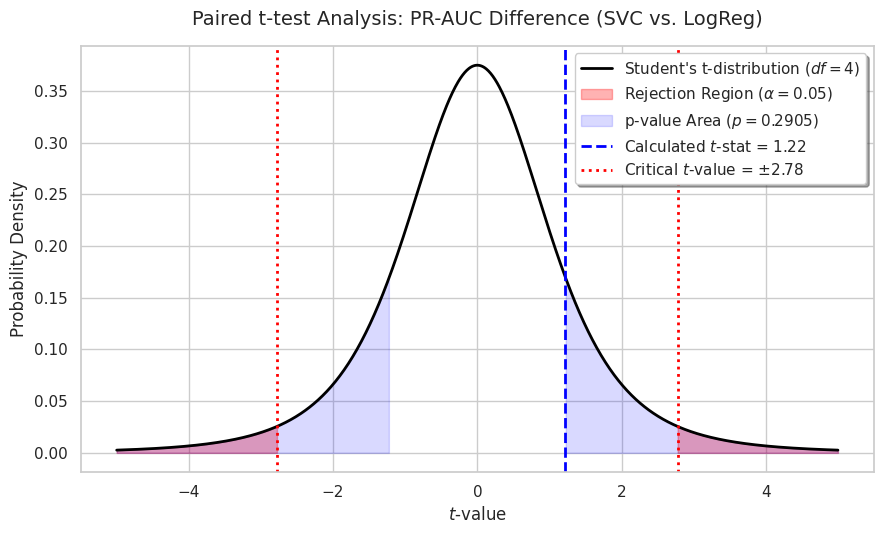

✅ Đã lưu ảnh thành công với tên 't_test_distribution.png'


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

# Dữ liệu thực tế từ 5-Fold của bạn
lr_folds = np.array([0.89845815, 0.92920544, 0.92422766, 0.93382417, 0.93481765])
svc_folds = np.array([0.90410354, 0.92835898, 0.93050778, 0.94042591, 0.93057245])

# Tính toán các giá trị thống kê
diff = svc_folds - lr_folds
n = len(diff)
df = n - 1

# t_stat = 1.1818, p_val = 0.2905
t_stat, p_val = stats.ttest_rel(svc_folds, lr_folds)
# t_crit = 2.776 (giá trị tới hạn ở mức 95% confidence, 2 đuôi)
t_crit = stats.t.ppf(0.975, df)

# --- VẼ BIỂU ĐỒ ---
sns.set_theme(style="whitegrid")
x = np.linspace(-5, 5, 1000)
y = stats.t.pdf(x, df) # Đường cong PDF của t-distribution

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(x, y, label=f"Student's t-distribution ($df={df}$)", color='black', linewidth=2)

# Tô màu vùng Rejection Region (Alpha = 0.05, tức 0.025 mỗi đuôi)
ax.fill_between(x, y, where=(x >= t_crit), color='red', alpha=0.3, label=r'Rejection Region ($\alpha=0.05$)')
ax.fill_between(x, y, where=(x <= -t_crit), color='red', alpha=0.3)

# Tô màu vùng p-value thực tế
ax.fill_between(x, y, where=(x >= t_stat), color='blue', alpha=0.15, label=f'p-value Area ($p={p_val:.4f}$)')
ax.fill_between(x, y, where=(x <= -t_stat), color='blue', alpha=0.15)

# Kẻ vạch t-statistic và t-critical
ax.axvline(t_stat, color='blue', linestyle='--', linewidth=2, label=f'Calculated $t$-stat = {t_stat:.2f}')
ax.axvline(t_crit, color='red', linestyle=':', linewidth=2, label=f'Critical $t$-value = $\pm${t_crit:.2f}')
ax.axvline(-t_crit, color='red', linestyle=':', linewidth=2)

# Trang trí
ax.set_title("Paired t-test Analysis: PR-AUC Difference (SVC vs. LogReg)", fontsize=14, pad=15)
ax.set_xlabel("$t$-value", fontsize=12)
ax.set_ylabel("Probability Density", fontsize=12)
ax.legend(loc='upper right', frameon=True, shadow=True)

plt.tight_layout()
plt.savefig('t_test_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Đã lưu ảnh thành công với tên 't_test_distribution.png'")

## 4. Chatbot Integration
Build functions to predict using the weights of Logistic Regression.

In [ ]:
import numpy as np
import pandas as pd

def pulsar_ai_diagnostic(input_features, logreg_model, svc_model, feature_names):
    """
    Hệ thống chẩn đoán Pulsar (XAI Diagnostic Interface) đã được tối ưu hóa.
    """
    # Đảm bảo đầu vào là 2D array để các model của sklearn không báo lỗi
    if len(input_features.shape) == 1:
        input_features = input_features.reshape(1, -1)

    # 1. Dự đoán xác suất từ 2 mô hình (Tuyến tính & Phi tuyến)
    prob_lr = logreg_model.predict_proba(input_features)[0][1]
    prob_svc = svc_model.predict_proba(input_features)[0][1]

    # Quyết định cuối cùng (Ưu tiên RBF SVC vì PR-AUC cao hơn sau tuning)
    is_pulsar = prob_svc > 0.5

    # 2. Giải thích bằng trọng số của Logistic Regression (Global Explainability)
    weights = logreg_model.coef_[0]
    values = input_features[0]
    contributions = weights * values

    # Sắp xếp các đặc trưng đóng góp từ cao xuống thấp
    indices = np.argsort(contributions)[::-1]

    print("\n" + "╔" + "═"*50 + "╗")
    print("║" + " "*12 + "HTRU2 PULSAR DIAGNOSTIC AGENT" + " "*13 + "║")
    print("╚" + "═"*50 + "╝")

    if is_pulsar:
        print(f"⚠️  TRẠNG THÁI: PHÁT HIỆN ỨNG VIÊN PULSAR")
        print(f"   - Độ tin cậy (RBF SVC): {prob_svc:.2%}")
        print(f"   - Độ tin cậy (LogReg):  {prob_lr:.2%}")
        print("\n🧐 PHÂN TÍCH HÌNH THÁI TÍN HIỆU (XAI):")

        # Hiển thị Top 2 đặc trưng đóng góp mạnh nhất
        for i in range(2):
            idx = indices[i]
            print(f"   [+] {feature_names[idx]:<20}: Đóng góp mạnh vào cấu trúc xung.")

        if 'kurtosis' in str(feature_names[indices[0]]).lower():
            print("\n💡 NHẬN ĐỊNH VẬT LÝ: Tín hiệu có độ nhọn (Kurtosis) đặc trưng,\n"
                  "   vượt xa ngưỡng nhiễu RFI thông thường.")
    else:
        print(f"✅  TRẠNG THÁI: NHIỄU NỀN / RFI")
        print(f"   - Xác suất Pulsar: {prob_svc:.2%}")
        print("\n🧐 LÝ DO LOẠI TRỪ:")
        # Hiển thị đặc trưng làm giảm khả năng là pulsar nhất
        worst_idx = np.argmin(contributions)
        print(f"   [-] {feature_names[worst_idx]:<20}: Chỉ số này quá thấp để hình thành xung.")
        print("\n💡 NHẬN ĐỊNH VẬT LÝ: Cấu trúc tín hiệu không ổn định,\n"
              "   tương đồng với các nguồn nhiễu nhân tạo (RFI).")

    print("═"*52 + "\n")

# --- DEMO CHẠY THỬ (ĐÃ FIX LỖI INDEX) ---

# Đảm bảo các model đã được huấn luyện tốt nhất
logreg_final = trained_models['Logistic Regression']
svc_final = trained_models['RBF SVC']
feature_cols = X.columns # Danh sách tên 8 đặc trưng

# Chuyển y_test thành array để lấy vị trí chính xác
y_test_array = np.array(y_test).flatten()

print("--- BẮT ĐẦU THỰC NGHIỆM CHẨN ĐOÁN ---")

# Kiểm tra nếu dữ liệu là DataFrame thì dùng .iloc, nếu là Array thì dùng index thường
def get_sample(data, index):
    if isinstance(data, pd.DataFrame):
        return data.iloc[[index]].values
    return data[index].reshape(1, -1)

# TEST 1: Một mẫu Pulsar thật
pulsar_indices = np.where(y_test_array == 1)[0]
if len(pulsar_indices) > 0:
    sample_p = get_sample(X_test_scaled, pulsar_indices[0])
    pulsar_ai_diagnostic(sample_p, logreg_final, svc_final, feature_cols)

# TEST 2: Một mẫu Nhiễu thật
noise_indices = np.where(y_test_array == 0)[0]
if len(noise_indices) > 0:
    sample_n = get_sample(X_test_scaled, noise_indices[0])
    pulsar_ai_diagnostic(sample_n, logreg_final, svc_final, feature_cols)

--- BẮT ĐẦU THỰC NGHIỆM CHẨN ĐOÁN ---

╔══════════════════════════════════════════════════╗
║            HTRU2 PULSAR DIAGNOSTIC AGENT             ║
╚══════════════════════════════════════════════════╝
⚠️  TRẠNG THÁI: PHÁT HIỆN ỨNG VIÊN PULSAR
   - Độ tin cậy (RBF SVC): 100.00%
   - Độ tin cậy (LogReg):  100.00%

🧐 PHÂN TÍCH HÌNH THÁI TÍN HIỆU (XAI):
   [+] Profile_skewness    : Đóng góp mạnh vào cấu trúc xung.
   [+] DM_stdev            : Đóng góp mạnh vào cấu trúc xung.
════════════════════════════════════════════════════


╔══════════════════════════════════════════════════╗
║            HTRU2 PULSAR DIAGNOSTIC AGENT             ║
╚══════════════════════════════════════════════════╝
✅  TRẠNG THÁI: NHIỄU NỀN / RFI
   - Xác suất Pulsar: 0.30%

🧐 LÝ DO LOẠI TRỪ:
   [-] Profile_skewness    : Chỉ số này quá thấp để hình thành xung.

💡 NHẬN ĐỊNH VẬT LÝ: Cấu trúc tín hiệu không ổn định,
   tương đồng với các nguồn nhiễu nhân tạo (RFI).
════════════════════════════════════════════════════



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


/tmp/ipykernel_460/2079402561.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


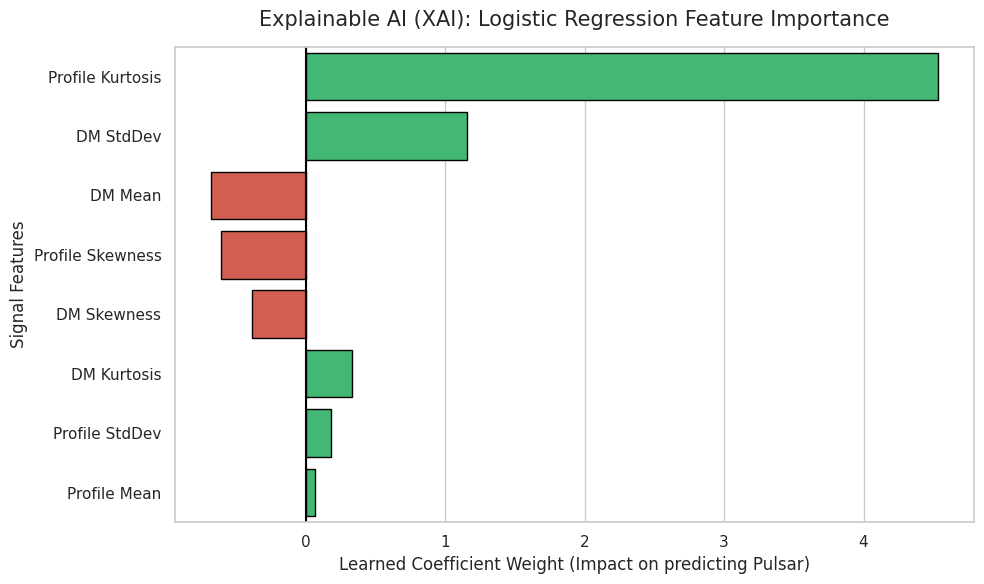

✅ Đã lưu ảnh thành công: 'xai_feature_importance.png'


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from ucimlrepo import fetch_ucirepo

# 1. Load và chuẩn bị dữ liệu
htru2 = fetch_ucirepo(id=372)
X = htru2.data.features
y = htru2.data.targets

# Đổi tên cột cho đẹp và dễ đọc trên biểu đồ
feature_names = [
    'Profile Mean', 'Profile StdDev', 'Profile Kurtosis', 'Profile Skewness',
    'DM Mean', 'DM StdDev', 'DM Kurtosis', 'DM Skewness'
]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Train mô hình LogReg tối ưu (C=0.1 như trong bài)
logreg = LogisticRegression(C=0.1, class_weight='balanced', solver='liblinear', random_state=42)
logreg.fit(X_scaled, y.values.ravel())

# 3. Lấy trọng số (Coefficients)
importance = logreg.coef_[0]

# Tạo DataFrame để vẽ
df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance (Coefficient)': importance
})
# Sắp xếp theo độ lớn tuyệt đối
df_importance['Abs_Importance'] = df_importance['Importance (Coefficient)'].abs()
df_importance = df_importance.sort_values(by='Abs_Importance', ascending=False)

# 4. Vẽ biểu đồ XAI
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Phân màu: Xanh cho Positive (Ủng hộ Pulsar), Đỏ cho Negative (Phản đối)
colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in df_importance['Importance (Coefficient)']]

barplot = sns.barplot(
    x='Importance (Coefficient)',
    y='Feature',
    data=df_importance,
    palette=colors,
    edgecolor='black'
)

plt.title('Explainable AI (XAI): Logistic Regression Feature Importance', fontsize=15, pad=15)
plt.xlabel('Learned Coefficient Weight (Impact on predicting Pulsar)', fontsize=12)
plt.ylabel('Signal Features', fontsize=12)

# Thêm đường line số 0
plt.axvline(0, color='black', linewidth=1.5)

plt.tight_layout()
plt.savefig('xai_feature_importance.png', dpi=300)
plt.show()

print("✅ Đã lưu ảnh thành công: 'xai_feature_importance.png'")

## 6. Conclusion
Conclude performances & recommend realistic solutions.

Model                | ROC-AUC    | PR-AUC     | Chênh lệch (ROC - PR)
----------------------------------------------------------------------
Logistic Regression  | 0.9724     | 0.9317     | 0.0407
RBF SVC              | 0.9730     | 0.9322     | 0.0408


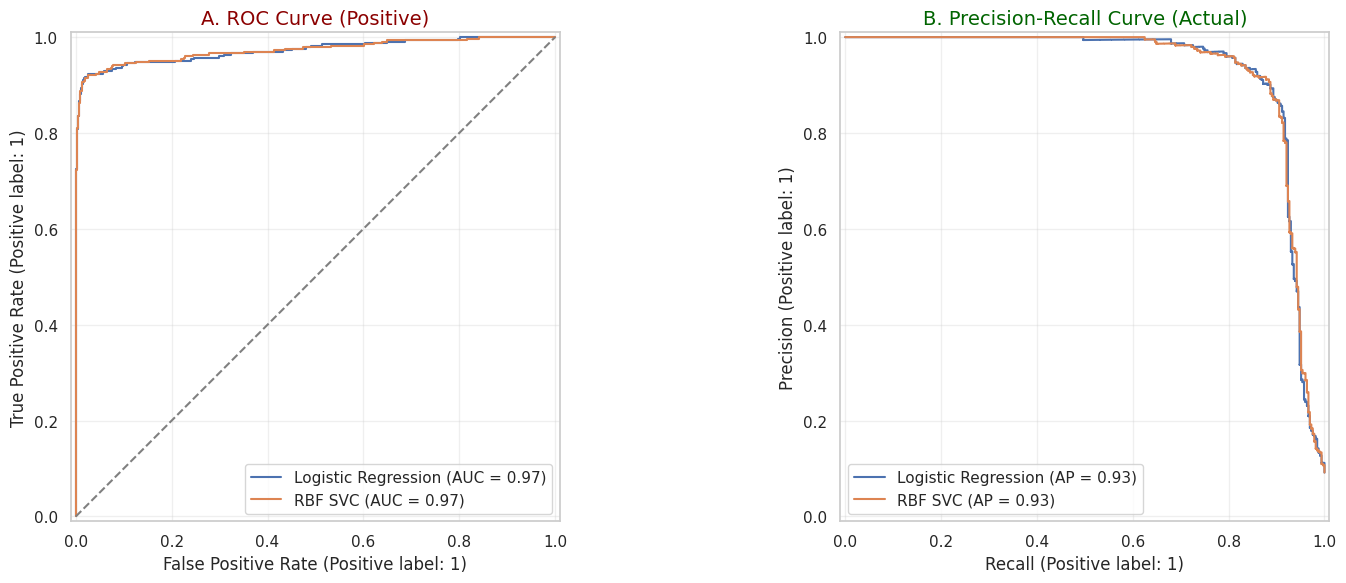

In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score, RocCurveDisplay, PrecisionRecallDisplay

# ==========================================================
# SO SÁNH ROC-AUC VÀ PR-AUC
# Mục tiêu: Chứng minh sự "lạc quan tếu" của ROC trên dữ liệu mất cân bằng
# ==========================================================

# 1. Tạo bảng so sánh số liệu
print(f"{'Model':<20} | {'ROC-AUC':<10} | {'PR-AUC':<10} | {'Chênh lệch (ROC - PR)':<20}")
print("-" * 70)

results_comparison = []

for name, model in trained_models.items():
    if name == "Majority (Baseline)": continue

    # Dự đoán xác suất trên tập Test
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    y_true = y_test # Hoặc y_test_array nếu bạn đã sửa lỗi index

    # Tính toán 2 chỉ số
    roc_score = roc_auc_score(y_true, y_prob)
    pr_score = average_precision_score(y_true, y_prob)
    diff = roc_score - pr_score

    print(f"{name:<20} | {roc_score:.4f}     | {pr_score:.4f}     | {diff:.4f}")
    results_comparison.append([name, roc_score, pr_score])

# 2. Vẽ biểu đồ song song (Side-by-Side)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Vẽ ROC Curve (Bên trái)
for name, model in trained_models.items():
    if name == "Majority (Baseline)": continue
    RocCurveDisplay.from_estimator(model, X_test_scaled, y_test, ax=ax1, name=name)

ax1.set_title("A. ROC Curve (Positive)", fontsize=14, color='darkred')
ax1.plot([0, 1], [0, 1], linestyle='--', color='grey') # Đường ngẫu nhiên
ax1.grid(True, alpha=0.3)

# Vẽ PR Curve (Bên phải)
for name, model in trained_models.items():
    if name == "Majority (Baseline)": continue
    PrecisionRecallDisplay.from_estimator(model, X_test_scaled, y_test, ax=ax2, name=name)

ax2.set_title("B. Precision-Recall Curve (Actual)", fontsize=14, color='darkgreen')
ax2.grid(True, alpha=0.3)
ax2.legend(loc='lower left')

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_validate
from ucimlrepo import fetch_ucirepo

# 1. Tải và chuẩn bị dữ liệu
print("Đang tải dữ liệu HTRU2...")
htru2 = fetch_ucirepo(id=372)
X = htru2.data.features
y = htru2.data.targets.values.ravel()

# Chuẩn hóa Z-score
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Khởi tạo mô hình với tham số tối ưu (SVC bắt buộc probability=True để tính PR-AUC)
logreg = LogisticRegression(C=0.1, class_weight='balanced', solver='liblinear', random_state=42)
svc = SVC(C=100, gamma=0.001, kernel='rbf', class_weight='balanced', probability=True, random_state=42)

# 3. Cấu hình 5-Fold Stratified CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("\nĐang đo lường thời gian huấn luyện (Fit Time) qua 5-Fold CV...")
print("Lưu ý: SVC sẽ mất một lúc do phải tính toán probability...")

# 4. Chạy CV và trích xuất mảng thời gian huấn luyện (fit_time)
cv_results_lr = cross_validate(logreg, X_scaled, y, cv=cv, return_train_score=False)
cv_results_svc = cross_validate(svc, X_scaled, y, cv=cv, return_train_score=False)

# 5. Tính toán Mean và Std của thời gian huấn luyện (đơn vị: giây)
lr_time_mean = np.mean(cv_results_lr['fit_time'])
lr_time_std = np.std(cv_results_lr['fit_time'])

svc_time_mean = np.mean(cv_results_svc['fit_time'])
svc_time_std = np.std(cv_results_svc['fit_time'])

# 6. In kết quả chuẩn định dạng để đưa vào bài báo (Mean ± Std)
print("\n" + "="*50)
print(" KẾT QUẢ THỜI GIAN HUẤN LUYỆN (TRAINING TIME)")
print("="*50)
print(f"Logistic Regression : {lr_time_mean:.4f} ± {lr_time_std:.4f} (s)")
print(f"RBF SVC             : {svc_time_mean:.4f} ± {svc_time_std:.4f} (s)")
print("-" * 50)

# Tính tỷ lệ chênh lệch
speed_diff = svc_time_mean / lr_time_mean
print(f"💡 KẾT LUẬN: RBF SVC chậm gấp ~{speed_diff:.1f} lần so với LogReg.")
print("="*50)

Đang tải dữ liệu HTRU2...

Đang đo lường thời gian huấn luyện (Fit Time) qua 5-Fold CV...
Lưu ý: SVC sẽ mất một lúc do phải tính toán probability...

 KẾT QUẢ THỜI GIAN HUẤN LUYỆN (TRAINING TIME)
Logistic Regression : 0.2133 ± 0.0571 (s)
RBF SVC             : 24.2758 ± 13.2501 (s)
--------------------------------------------------
💡 KẾT LUẬN: RBF SVC chậm gấp ~113.8 lần so với LogReg.
